
# Do Age and Treatment Interact in Predicting Depression Therapy Outcomes?



In [22]:
!pip install ISLP


## 1. Data and Research Question

This dataset contains observations from a study comparing three treatments for severe depression. The variables used in this analysis are:

- `age`: age of the patient
- `TRT`: treatment group (A, B, or C)
- `y`: effectiveness score of the therapy

The main research question is:

**Does the effect of age on treatment effectiveness depend on the treatment group?**

To answer this, I compare an additive regression model with a model that includes interaction terms between age and treatment.


In [15]:
# Run this cell to import the packages used and to load the data
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)



# Load dataset
url = 'https://online.stat.psu.edu/stat501/sites/stat501/files/data/depression.txt'
df = pd.read_csv(url, sep='\t')
df = df.drop(['x2','x3'], axis = 1)

# Preview data
df.head()

,y,age,TRT
0,56,21,A
1,41,23,B
2,40,30,B
3,28,19,C
4,55,28,A


In [16]:
df.describe()

,y,age
count,36.000000,36.000000
mean,55.166667,44.111111
std,12.415428,14.628305
min,25.000000,19.000000
25%,46.750000,32.250000
50%,58.000000,44.000000
75%,63.250000,56.500000
max,73.000000,67.000000


In [17]:
df['TRT'].value_counts()

TRT
A    12
B    12
C    12
Name: count, dtype: int64

## 2. Exploratory Data Analysis

C:\Users\wwg7j\Neuer Ordner\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


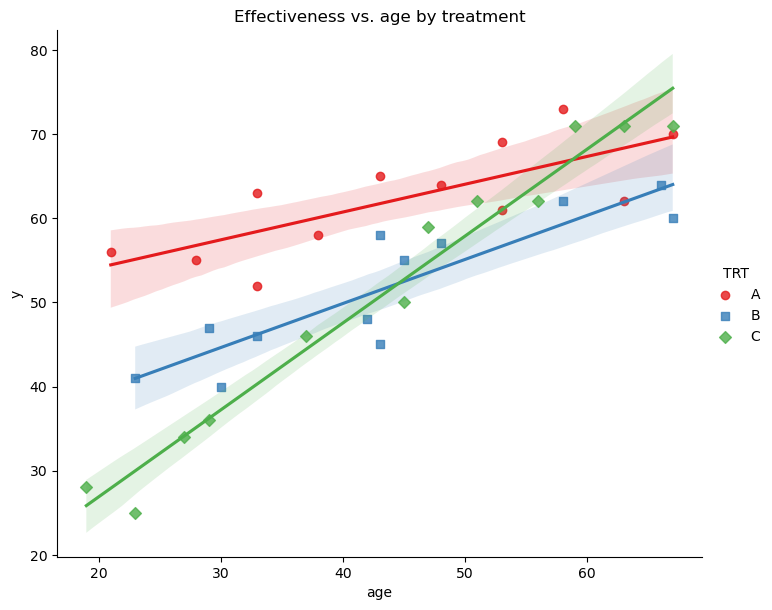

In [18]:
# Visualize relationship
sns.lmplot(x='age', y='y', hue='TRT', data=df, markers=['o', 's', 'D'], palette='Set1', height=6, aspect=1.2)
plt.title('Effectiveness vs. age by treatment')
plt.show()

The scatterplot suggests that treatment effectiveness tends to increase with age, but the strength of this relationship appears to differ across treatment groups. In particular, the regression lines are not parallel, which provides an initial indication that interaction effects may be present.

## 3. Additive Regression Model

In [6]:
# solution

# Transform treatment datatype to category
df['TRT'] = df['TRT'].astype('category')

# Fit baseline model
design_baseline = MS(['age','TRT']).fit(df)
X_baseline = design_baseline.transform(df)
y = df['y']
model_baseline = sm.OLS(y,X_baseline).fit()
print(model_baseline.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     38.71
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           9.29e-11
Time:                        16:26:31   Log-Likelihood:                -113.68
No. Observations:                  36   AIC:                             235.4
Df Residuals:                      32   BIC:                             241.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     32.5433      3.581      9.088      0.0

The additive model explains a substantial share of the variation in therapy effectiveness (`R² = 0.784`). The overall model is statistically significant, indicating that the predictors are jointly related to the response.

Age has a positive coefficient, suggesting that older patients tend to show higher treatment effectiveness on average. Using treatment A as the reference category, the negative coefficients for treatments B and C indicate lower expected effectiveness compared with treatment A, holding age constant.

However, this model assumes that the effect of age is identical across all treatment groups. This assumption is tested in the next step by adding interaction terms.

## 4. Interaction Model

Now I fit a model additionally to the model from Task 2 that includes interaction terms between `age` and `TRT`.

In [7]:
# solution

#create design matrix
design_interaction = MS(['age','TRT',('age', 'TRT')]).fit(df)
X_interaction = design_interaction.transform(df)

# Fit interaction model
model_interaction = sm.OLS(y,X_interaction).fit()
print(model_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     64.04
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           4.26e-15
Time:                        16:26:31   Log-Likelihood:                -97.024
No. Observations:                  36   AIC:                             206.0
Df Residuals:                      30   BIC:                             215.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     47.5156      3.825     12.422      0.0

The interaction model improves the fit substantially (`R² = 0.914`, adjusted `R² = 0.900`). This suggests that allowing the age-effect to vary across treatment groups captures important structure in the data.

The interaction term between age and treatment C is statistically significant, indicating that the effect of age differs clearly between treatments A and C. The interaction term for treatment B is positive as well, but it is not statistically significant at the 5% level.

Overall, the results suggest that treatment effectiveness should not be interpreted as the sum of separate age and treatment effects alone. Instead, the influence of age depends at least partly on the treatment received.


## 5. Model Comparison

Comparing both models using R-squared and adjusted R-squared.

In [8]:

comparison = pd.DataFrame({
    "Model": ["Baseline", "Interaction"],
    "R-squared": [model_baseline.rsquared, model_interaction.rsquared],
    "Adj. R-squared": [model_baseline.rsquared_adj, model_interaction.rsquared_adj]
})
comparison


,Model,R-squared,Adj. R-squared
0,Baseline,0.783953,0.763698
1,Interaction,0.914338,0.900061


In [9]:
print('Effectivity of treatment A:          y = ', model_interaction.params['intercept'], ' + ', model_interaction.params['age'], ' * age') 
print('Effectivity of treatment B:          y = ', model_interaction.params['intercept'] + model_interaction.params['TRT[B]'], ' + ', model_interaction.params['age'] + model_interaction.params['age:TRT[B]'], ' * age') 
print('Effectivity of treatment C:          y = ', model_interaction.params['intercept'] + model_interaction.params['TRT[C]'], ' + ', model_interaction.params['age'] + model_interaction.params['age:TRT[C]'], ' * age')

Effectivity of treatment A:          y =  47.51559132059224  +  0.33050725678976317  * age
Effectivity of treatment B:          y =  28.918206102562536  +  0.5236841115166027  * age
Effectivity of treatment C:          y =  6.211381193582056  +  1.0333908712753646  * age


The interaction model performs better than the additive model. The `R²` increases from 78.4% to 91.4%, and the adjusted `R²` increases from 76.4% to 90.0%.

This improvement indicates that the relationship between age and treatment effectiveness is not the same across treatment groups. The interaction model provides a more nuanced and more accurate representation of the data.

Using treatment A as the reference group, the fitted regression lines are:

- **Treatment A:** `y = 47.52 + 0.33 * age`
- **Treatment B:** `y = 28.92 + 0.52 * age`
- **Treatment C:** `y = 6.21 + 1.03 * age`

These equations show that treatment C has the steepest age-related increase in predicted effectiveness.

## 6. Regression Diagnostics

Now that we have fitted our final model (with interaction terms), let’s assess how well it meets the assumptions of linear regression.

We’ll perform the following diagnostics:

- **Residual Plot**: Check for randomness in residuals.
- **Standardized Residuals**: Identify potential outliers. 
- **Leverage**: Identify observations that have unusual predictor values.

### ➤ Why?
These checks help us validate our model's assumptions and identify points that may disproportionately affect model results.

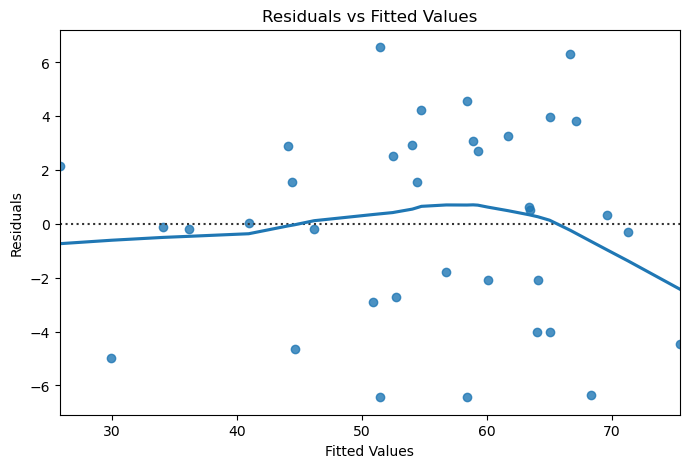

In [23]:

# Residuals and fitted values
fitted_vals = model_interaction.fittedvalues
residuals = model_interaction.resid
standardized_resid = model_interaction.get_influence().resid_studentized_internal

# Residual Plot
plt.figure(figsize=(8, 5))
sns.residplot(x=fitted_vals, y=residuals, lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [24]:
# Outlier detection
outliers = df[np.abs(standardized_resid) > 3]
print(f"Number of potential outliers (|standardized residual| > 3): {len(outliers)}")
outliers

Number of potential outliers (|standardized residual| > 3): 0


,y,age,TRT


In [25]:
# Leverage analysis
influence = model_interaction.get_influence()
leverage = influence.hat_matrix_diag
cutoff = 2 * (model_interaction.df_model + 1) / len(df)
high_leverage = df[leverage > cutoff]

print(f"Cutoff for high leverage: {cutoff:.3f}")
print(f"Number of high leverage points: {len(high_leverage)}")
high_leverage

Cutoff for high leverage: 0.333
Number of high leverage points: 0


,y,age,TRT


The diagnostic checks do not reveal major problems. The residual plot does not show a strong systematic pattern, which supports the linearity assumption. No observations exceed the threshold for standardized residuals above 3, so there is no strong evidence of extreme outliers.

Likewise, no observations exceed the leverage cutoff, which suggests that the fitted model is not being driven by a small number of unusual predictor combinations.

## 7. Prediction for a New Patient

predict the effectiveness for a **new patient**:

- Age = 45
- Treatment = A

### ➤ Why?
Understanding prediction vs. confidence intervals is critical:
- **Confidence Interval**: Tells us where the **mean** outcome is likely to lie.
- **Prediction Interval**: Tells us where a **single new observation** is likely to fall, accounting for more uncertainty.

In [20]:
# Create new patient
new_patient_raw = pd.DataFrame({'age': [45], 'TRT': ['A']})
new_patient_raw['TRT'] = new_patient_raw['TRT'].astype('category')
new_patient = design_interaction.transform(new_patient_raw)

# Predict
prediction = model_interaction.get_prediction(new_patient)
summary = prediction.summary_frame(alpha=0.05)
summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,62.388418,1.133106,60.074308,64.702528,54.045328,70.731508


For a 45-year-old patient receiving treatment A, the predicted effectiveness is approximately 62.39.

The 95% confidence interval describes the plausible range for the **mean effectiveness** among similar patients with the same characteristics. The 95% prediction interval is wider because it reflects the uncertainty for a **single new individual outcome**.

This difference is expected, since individual outcomes vary more than group averages.

## Conclusion

This analysis shows that treatment effectiveness is associated not only with age and treatment group, but also with their interaction.

The interaction model fits the data substantially better than the additive model, indicating that the effect of age differs across treatments. In particular, treatment C shows a clearly stronger age-related increase in predicted effectiveness than treatment A.

Overall, the results illustrate why interaction terms can be important in regression modeling: they allow us to capture relationships that would be hidden by a simpler additive specification.